In [91]:
import os, sys
import networkx as nx
import json
import time
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter
import itertools

In [71]:
results = os.path.join('./results', 'results.json')
with open(results, 'r') as f:
    results = json.load(f)
times = [], []
labels = []
for k, v in results.items():
    times[0].append(v['bmssp'])
    times[1].append(v['dijkstra'])
    labels.append(str(pd.to_datetime(k)).split(' ')[0])

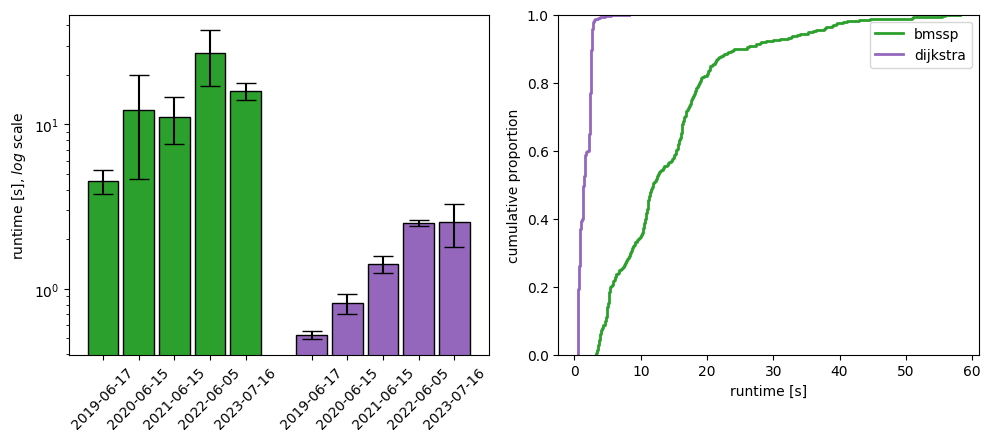

In [114]:
fig = plt.figure(figsize=(10., 4.5))
ax = fig.add_subplot(1, 2, 1)
x, barWidth = 0, 0.3
ticks = []
for i, t in enumerate(times[0] + times[1]):
    ticks.append(x)
    t, e = np.asarray(t).mean(), np.std(np.asarray(t))
    ax.bar(x, t, width=barWidth, yerr=e, capsize=7, edgecolor='black',
           color='tab:green' if i < len(times[0]) else 'tab:purple',)
    x += barWidth + 0.05
    if i == len(times[0]) - 1:
        x += 0.3
    
#xfmt = ScalarFormatter(useMathText=True)
#xfmt.set_powerlimits((0,0))
#ax.yaxis.set_major_formatter(xfmt)
ax.set_xticks(ticks, labels * 2)
ax.tick_params(axis='x', labelrotation=45)

ax.set_yscale('log')
ax.set_ylabel('runtime [s], $log$ scale')

ax = fig.add_subplot(1, 2, 2)
x = list(itertools.chain.from_iterable(times[0]))
ax.ecdf(x, label='bmssp', color='tab:green', linewidth=2)
x = list(itertools.chain.from_iterable(times[1]))
ax.ecdf(x, label='dijkstra', color='tab:purple', linewidth=2)
ax.set_xlabel('runtime [s]')
ax.set_ylabel('cumulative proportion')
ax.legend()


fig.tight_layout(pad=1.01)
fig.savefig(f'./results/fig01.pdf',
            dpi=600, bbox_inches='tight', format='pdf')
